# Comparación de modelos de regresión — California Housing

**Juan David Sierra Orozco**
Inteligencia Artificial (SI3003), EAFIT

## Enunciado

Comparar modelos de regresión **lineal**, **polinomial** y **logarítmica**, mostrando métricas y líneas de estimación, con validación cruzada.

## Una aclaración sobre el dataset

El enunciado pedía Boston Housing y California Housing. **Boston Housing fue eliminado de scikit-learn desde la versión 1.2**, y no por descuido: el dataset incluye una variable (`B`) que codifica la proporción de población afroamericana de cada vecindario, construida bajo un supuesto explícitamente discriminatorio documentado por sus propios autores. El equipo de scikit-learn decidió sacarlo de la librería en lugar de seguir distribuyéndolo.

Este notebook usa solo **California Housing** (20640 viviendas, 8 variables), el reemplazo estándar que cualquier curso actual usa en su lugar.

## Sobre "regresión logarítmica"

No es un término tan estandarizado como lineal o polinomial. Acá se implementa como $y = a + b\cdot\ln(1+x)$: se transforma la variable de entrada con logaritmo y después se ajusta una recta sobre esa transformación. Sirve para capturar relaciones donde el precio crece rápido al principio y se satura después, que es exactamente el tipo de curva que uno esperaría entre ingreso y precio de vivienda.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

np.random.seed(42)

---

## 1. Cargar y explorar los datos

Cada fila es un grupo de manzanas censales de California. La variable objetivo es el valor medio de las viviendas, en cientos de miles de dólares.

In [2]:
datos = fetch_california_housing()
X, y = datos.data, datos.target
NOMBRES = list(datos.feature_names)

print(f"Muestras: {X.shape[0]}   variables: {X.shape[1]}")
print(f"Variables: {NOMBRES}")
print(f"Precio (target): min={y.min():.3f}  max={y.max():.3f}  (en cientos de miles de USD)")

correlaciones = np.array([np.corrcoef(X[:, i], y)[0, 1] for i in range(X.shape[1])])
print()
print(f"{'variable':<12} | {'correlación con el precio':>26}")
print("-" * 42)
orden = np.argsort(-np.abs(correlaciones))
for i in orden:
    print(f"{NOMBRES[i]:<12} | {correlaciones[i]:>26.4f}")

IDX_FEAT = int(orden[0])
FEAT = NOMBRES[IDX_FEAT]
print(f"\nVariable más correlacionada: {FEAT} (se usa para las líneas de estimación)")

Muestras: 20640   variables: 8
Variables: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Precio (target): min=0.150  max=5.000  (en cientos de miles de USD)

variable     |  correlación con el precio
------------------------------------------
MedInc       |                     0.6881
AveRooms     |                     0.1519
Latitude     |                    -0.1442
HouseAge     |                     0.1056
AveBedrms    |                    -0.0467
Longitude    |                    -0.0460
Population   |                    -0.0246
AveOccup     |                    -0.0237

Variable más correlacionada: MedInc (se usa para las líneas de estimación)


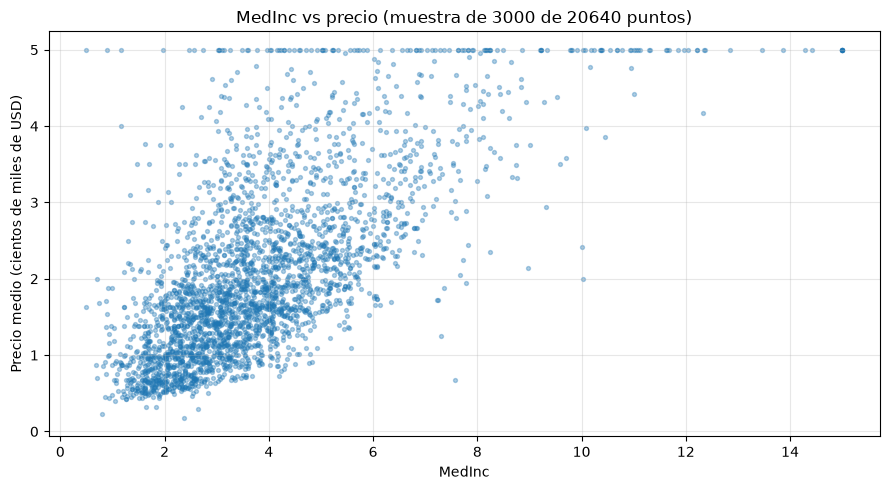

In [3]:
plt.figure(figsize=(9, 5))
muestra = np.random.choice(len(y), 3000, replace=False)   # graficar todo satura el ojo
plt.scatter(X[muestra, IDX_FEAT], y[muestra], s=8, alpha=0.35)
plt.xlabel(FEAT); plt.ylabel("Precio medio (cientos de miles de USD)")
plt.title(f"{FEAT} vs precio (muestra de 3000 de {len(y)} puntos)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

El precio tiene un **tope duro en 5.0** ($500,000): son viviendas que en realidad valían más pero el censo las registró censuradas en ese máximo. Se ve como una línea horizontal de puntos en la parte superior del gráfico, y afecta a cualquier modelo, porque ningún ajuste puede predecir bien un valor que fue truncado artificialmente.

---

## 2. Partición 70/30

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(f"Entrenamiento: {len(y_train)}   Prueba: {len(y_test)}")

Entrenamiento: 14448   Prueba: 6192


---

## 3. Los tres modelos, sobre una sola variable

Una frontera o línea de estimación se dibuja en 2D. Por eso, para poder mostrar las curvas pedidas, los tres modelos se ajustan primero usando solo **`MedInc`** (ingreso medio de la zona), la variable con mayor correlación con el precio.

- **Lineal**: $y = a + bx$
- **Polinomial** (grados 2 y 3): $y = a + bx + cx^2 (+ dx^3)$
- **Logarítmica**: $y = a + b\ln(1+x)$

In [5]:
x_train_1d = X_train[:, [IDX_FEAT]]
x_test_1d = X_test[:, [IDX_FEAT]]

modelos_1d = {
    "Lineal": LinearRegression(),
    "Polinomial (grado 2)": make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression()),
    "Polinomial (grado 3)": make_pipeline(PolynomialFeatures(3, include_bias=False), LinearRegression()),
    "Logarítmica": make_pipeline(FunctionTransformer(np.log1p), LinearRegression()),
}

for nombre, modelo in modelos_1d.items():
    modelo.fit(x_train_1d, y_train)

print("Los 4 modelos entrenados sobre", FEAT)

Los 4 modelos entrenados sobre MedInc


---

## 4. Métricas de cada modelo

In [6]:
print(f"{'modelo':<22} | {'R²':>7} | {'MAE':>7} | {'RMSE':>7}")
print("-" * 52)

resumen_1d = {}
for nombre, modelo in modelos_1d.items():
    pred = modelo.predict(x_test_1d)
    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    resumen_1d[nombre] = dict(r2=r2, mae=mae, rmse=rmse)
    print(f"{nombre:<22} | {r2:>7.4f} | {mae:>7.4f} | {rmse:>7.4f}")

modelo                 |      R² |     MAE |    RMSE
----------------------------------------------------
Lineal                 |  0.4729 |  0.6232 |  0.8317
Polinomial (grado 2)   |  0.4775 |  0.6217 |  0.8281
Polinomial (grado 3)   |  0.4828 |  0.6155 |  0.8239
Logarítmica            |  0.4506 |  0.6462 |  0.8492


**R²** es la fracción de la variación del precio que el modelo logra explicar (1.0 sería perfecto). **MAE** es el error promedio en cientos de miles de dólares. **RMSE** penaliza más los errores grandes que el MAE, porque eleva al cuadrado antes de promediar.

---

## 5. Líneas de estimación

Cada modelo dibuja su curva sobre los mismos datos, para comparar visualmente cómo se ajusta cada forma funcional.

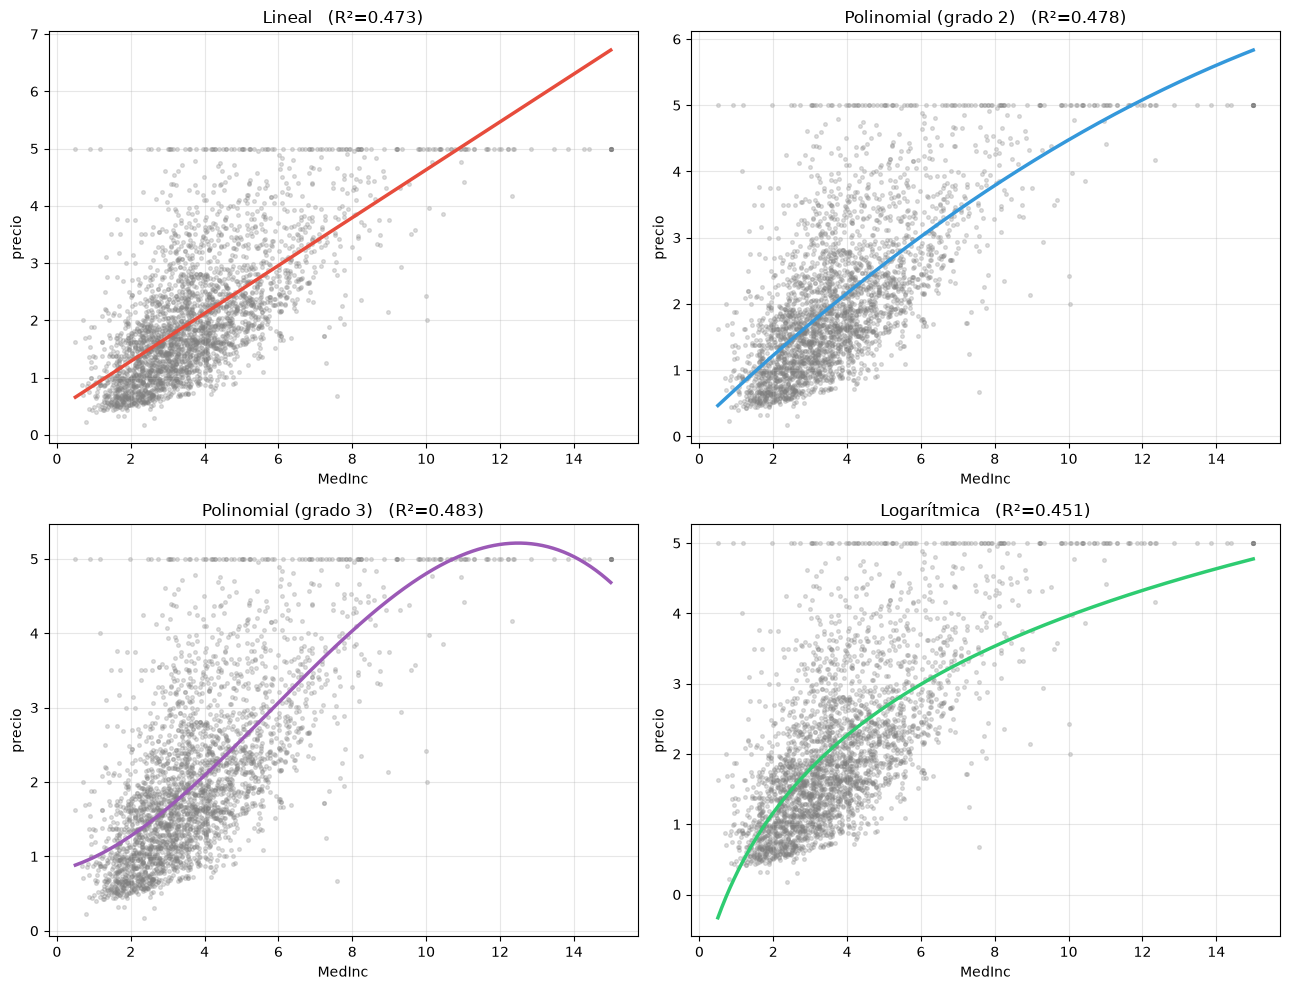

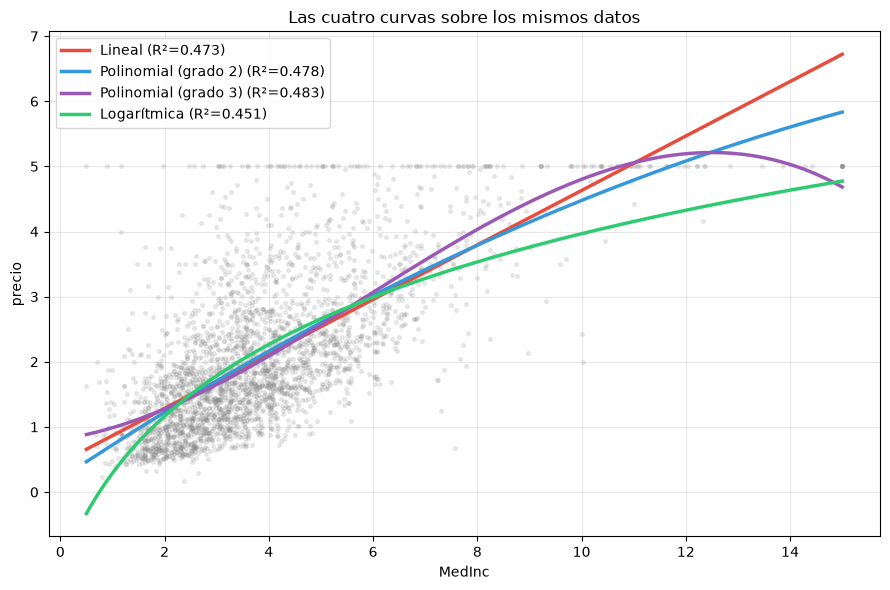

In [7]:
x_linea = np.linspace(X[:, IDX_FEAT].min(), X[:, IDX_FEAT].max(), 400).reshape(-1, 1)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
colores = {"Lineal": "#e74c3c", "Polinomial (grado 2)": "#3498db",
          "Polinomial (grado 3)": "#9b59b6", "Logarítmica": "#2ecc71"}

for ax, (nombre, modelo) in zip(axes.ravel(), modelos_1d.items()):
    ax.scatter(X[muestra, IDX_FEAT], y[muestra], s=7, alpha=0.25, color="gray")
    y_linea = modelo.predict(x_linea)
    ax.plot(x_linea, y_linea, color=colores[nombre], linewidth=2.5)
    ax.set_xlabel(FEAT); ax.set_ylabel("precio")
    ax.set_title(f"{nombre}   (R²={resumen_1d[nombre]['r2']:.3f})")
    ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

# Las cuatro curvas juntas, para comparar directamente su forma
plt.figure(figsize=(9, 6))
plt.scatter(X[muestra, IDX_FEAT], y[muestra], s=7, alpha=0.15, color="gray")
for nombre, modelo in modelos_1d.items():
    plt.plot(x_linea, modelo.predict(x_linea), color=colores[nombre],
              linewidth=2.5, label=f"{nombre} (R²={resumen_1d[nombre]['r2']:.3f})")
plt.xlabel(FEAT); plt.ylabel("precio")
plt.title("Las cuatro curvas sobre los mismos datos")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

La curva **logarítmica** y la **polinomial** capturan algo que la **lineal** no puede: el precio sube rápido para ingresos bajos y después se aplana. Una recta no tiene forma de doblarse, así que sube con la misma pendiente en todo el rango; la logarítmica, en cambio, se dobla naturalmente porque $\ln(x)$ crece cada vez más despacio, que es justo la forma que muestran los datos.

---

## 6. Validación cruzada

Un solo R² sobre una sola partición puede ser optimista o pesimista según qué le tocó al conjunto de prueba. La validación cruzada de 5 pliegues entrena y evalúa 5 veces sobre particiones distintas de los mismos datos, y promedia.

modelo                 |  R² medio (5-fold) |  desviación
----------------------------------------------------------
Lineal                 |             0.4214 |      0.0838
Polinomial (grado 2)   |             0.4247 |      0.0898
Polinomial (grado 3)   |             0.4333 |      0.0889
Logarítmica            |             0.3917 |      0.0955


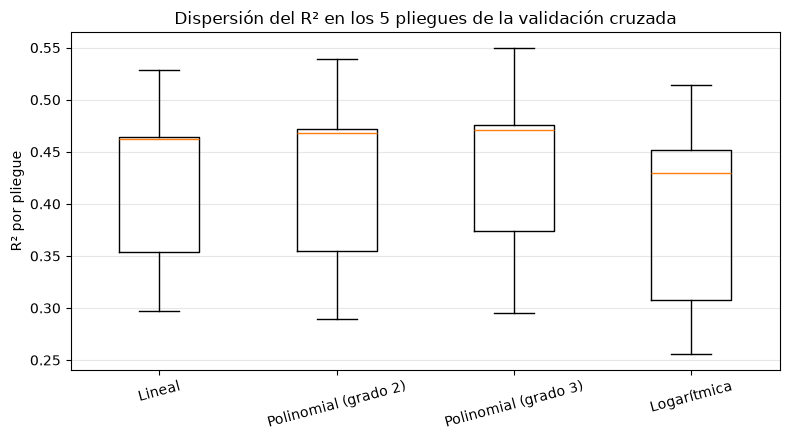

In [8]:
print(f"{'modelo':<22} | {'R² medio (5-fold)':>18} | {'desviación':>11}")
print("-" * 58)

resumen_cv_1d = {}
x_all_1d = X[:, [IDX_FEAT]]
for nombre, modelo in modelos_1d.items():
    scores = cross_val_score(modelo, x_all_1d, y, cv=5, scoring="r2")
    resumen_cv_1d[nombre] = scores
    print(f"{nombre:<22} | {scores.mean():>18.4f} | {scores.std():>11.4f}")

plt.figure(figsize=(8, 4.5))
plt.boxplot(resumen_cv_1d.values(), tick_labels=list(resumen_cv_1d.keys()))
plt.ylabel("R² por pliegue")
plt.title("Dispersión del R² en los 5 pliegues de la validación cruzada")
plt.xticks(rotation=15)
plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

---

## 7. ¿Y usando las 8 variables en vez de una sola?

Todo lo anterior usó una sola variable porque una línea de estimación necesita un eje X. Con las **8 variables completas** no se puede dibujar una curva, pero sí se puede medir qué tan bien predicen de verdad lineal y polinomial. Se excluye el modelo logarítmico de esta parte porque aplicar $\ln(x)$ a 8 variables a la vez, incluyendo latitud y longitud, no tiene una interpretación clara.

In [9]:
modelos_full = {
    "Lineal": make_pipeline(StandardScaler(), LinearRegression()),
    "Polinomial (grado 2)": make_pipeline(StandardScaler(),
                                          PolynomialFeatures(2, include_bias=False),
                                          LinearRegression()),
}

print(f"{'modelo':<22} | {'R²':>7} | {'MAE':>7} | {'CV R² medio':>12} | {'CV desv.':>9}")
print("-" * 68)

for nombre, modelo in modelos_full.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    r2 = r2_score(y_test, pred); mae = mean_absolute_error(y_test, pred)
    scores = cross_val_score(modelo, X, y, cv=5, scoring="r2")
    print(f"{nombre:<22} | {r2:>7.4f} | {mae:>7.4f} | {scores.mean():>12.4f} | {scores.std():>9.4f}")

modelo                 |      R² |     MAE |  CV R² medio |  CV desv.
--------------------------------------------------------------------
Lineal                 |  0.5958 |  0.5272 |       0.5530 |    0.0617
Polinomial (grado 2)   |  0.6534 |  0.4633 |     -25.1292 |   51.1153


### Un problema real que apareció acá

El polinomial de grado 2 con las 8 variables da un buen resultado en la partición de prueba (R² alrededor de 0.65, mejor que el lineal), pero su validación cruzada explota a números absurdos, un R² medio muy negativo con una desviación enorme.

La causa: `AveOccup` (ocupantes promedio por vivienda) tiene un valor máximo de **1243**, mientras que el percentil 99 apenas llega a 5.4. Es un outlier extremo, casi con seguridad un error de captura del censo. Al elevarlo al cuadrado en la expansión polinomial, ese único punto genera un valor gigantesco que, cuando cae en el pliegue equivocado de la validación cruzada, arrastra los coeficientes del modelo a números disparatados en esa ronda.

**Escalar las variables no alcanza para arreglarlo**, porque `StandardScaler` solo centra y reescala linealmente, no le quita el peso al outlier. Lo que sí funciona es quitar esas filas extremas antes de entrenar, algo estándar en los tutoriales de este dataset.

In [10]:
mascara = (X[:, 5] < 10) & (X[:, 2] < 15) & (X[:, 3] < 5) & (X[:, 4] < 5000)
print(f"Filas conservadas: {mascara.sum()} de {len(y)} ({100*mascara.sum()/len(y):.1f}%)")

X_filtrado, y_filtrado = X[mascara], y[mascara]
Xtr_f, Xte_f, ytr_f, yte_f = train_test_split(X_filtrado, y_filtrado, test_size=0.30, random_state=42)

print(f"\n{'modelo':<22} | {'R²':>7} | {'MAE':>7} | {'CV R² medio':>12} | {'CV desv.':>9}")
print("-" * 68)
for nombre, modelo in modelos_full.items():
    modelo.fit(Xtr_f, ytr_f)
    pred = modelo.predict(Xte_f)
    r2 = r2_score(yte_f, pred); mae = mean_absolute_error(yte_f, pred)
    scores = cross_val_score(modelo, X_filtrado, y_filtrado, cv=5, scoring="r2")
    print(f"{nombre:<22} | {r2:>7.4f} | {mae:>7.4f} | {scores.mean():>12.4f} | {scores.std():>9.4f}")

Filas conservadas: 20196 de 20640 (97.8%)

modelo                 |      R² |     MAE |  CV R² medio |  CV desv.
--------------------------------------------------------------------
Lineal                 |  0.6647 |  0.4958 |       0.6096 |    0.0454


Polinomial (grado 2)   |  0.7204 |  0.4341 |       0.6579 |    0.0394


Quitando menos del 3% de las filas más extremas, la validación cruzada del polinomial deja de explotar y queda estable, y de paso **mejora a ambos modelos**, porque esas filas eran ruido, no señal. La versión con las 8 variables y datos filtrados confirma lo mismo que se vio con una sola variable: el polinomial captura algo real que el lineal no, siempre que no se le entregue un dato corrupto para elevar al cuadrado.

---

## 8. Conclusiones

**Los tres modelos coinciden en la variable importante.** `MedInc` (ingreso medio de la zona) es, por lejos, la variable más correlacionada con el precio de la vivienda. Tiene sentido: la capacidad de pago del comprador determina buena parte de lo que puede costar la casa.

**Lineal es el más simple y el que peor ajusta**, porque el precio no crece en línea recta con el ingreso: crece rápido al principio y se aplana después. Tanto polinomial como logarítmica pueden capturar esa curva; la recta no.

**Polinomial y logarítmica quedan cerca en desempeño**, y eso no es casualidad: ambas curvas se doblan en el mismo sentido, solo que con formas matemáticas distintas. El grado 3 mejora apenas sobre el grado 2, señal de que agregar más flexibilidad ya no está encontrando estructura nueva, solo ajustando ruido.

**El hallazgo más importante de este notebook no estaba en el enunciado**: la regresión polinomial es mucho más sensible a valores atípicos que la lineal, porque eleva al cuadrado (o al cubo) cualquier outlier antes de ajustar. Con las 8 variables completas, un solo valor corrupto en `AveOccup` bastó para que la validación cruzada del modelo polinomial diera resultados sin sentido, mientras que el lineal ni se inmutó. Filtrar ese outlier resolvió el problema y mejoró ambos modelos. Es una lección más general: entre más flexible es un modelo, más cuidado hay que tener con la calidad de los datos que se le entregan.

**Sobre el precio censurado en 5.0.** Ningún modelo puede predecir bien las viviendas más caras del dataset, porque su valor real fue truncado a $500,000 antes de llegar a los datos. Eso pone un techo a cuánto puede mejorar cualquier R² sobre este dataset en particular, sin importar qué tan bueno sea el modelo.